# tracing a driver's day, minute by minute

simple simulation on the full gurgaon grid (207 zones, 2m fare points):

- prices and trip times are interpolated to the minute from the 48 half-hour slots
- every minute, a random proportion `q` of the 206 destinations have a ride available (q is the knob to play with)
- the chosen ride's pickup is 1-5 minutes away (ola quotes assumed to be from the closest cab), then the trip runs its course, then the driver is free again
- three drivers: **random** picks any available ride, **greedy** picks the best fare per minute, **strategic** picks fare + future value of the destination (from the bellman solve)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(7)

## load the grid and build minute-level pricing

fares and trip times become functions of the minute: linear interpolation between the two nearest half-hour slots

In [2]:
df = pd.read_parquet("city_grid.parquet")
hexes = sorted(df.from_id.unique())
names = df.drop_duplicates("from_id").set_index("from_id")["from_name"].to_dict()
idx = {h: i for i, h in enumerate(hexes)}
n, M = len(hexes), 1440

t_arr = (df.slot.str[:2].astype(int) * 2 + (df.slot.str[3:] == "30")).values
price = np.zeros((48, n, n))
trip = np.zeros((48, n, n))
price[t_arr, df.from_id.map(idx).values, df.to_id.map(idx).values] = df.price.values
trip[t_arr, df.from_id.map(idx).values, df.to_id.map(idx).values] = df.trip_min.values


def at_minute(tensor, t):
    """interpolate a (48, n, n) slot tensor to minute t -> (n, n)"""
    s = min(t // 30, 47)
    s2 = min(s + 1, 47)
    w = (t % 30) / 30
    return (1 - w) * tensor[s] + w * tensor[s2]


print(f"{n} zones | fare 9:00 vs 9:17 vs 9:30 for one pair:",
      f"{price[18, 0, 5]:.0f}, {at_minute(price, 557)[0, 5]:.0f}, {price[19, 0, 5]:.0f} inr")

207 zones | fare 9:00 vs 9:17 vs 9:30 for one pair: 180, 186, 190 inr


## the strategic driver's compass

backward induction over every (zone, minute): V[h, t] = the most a driver there can still earn by midnight, assuming an average 3-minute pickup. the strategic driver ranks rides by fare + V(destination, arrival)

In [3]:
PICKUP_AVG = 3
V = np.zeros((n, M + 120))
cols = np.arange(n)[None, :]

for t in range(M - 1, -1, -1):
    p_t = at_minute(price, t)
    busy_t = (PICKUP_AVG + np.ceil(at_minute(trip, t))).astype(int)
    cand = p_t + V[cols, t + busy_t]
    np.fill_diagonal(cand, -np.inf)
    V[:, t] = np.maximum(cand.max(1), V[:, t + 1])

print(f"value of a perfect 8am start: {V[:, 480].max():,.0f} inr")

value of a perfect 8am start: 16,284 inr


## the simulation

one shift = 8am to midnight. each idle minute a fraction q of destinations offer a ride; the driver picks one (by strategy), spends 1-5 random minutes reaching the pickup, drives the trip, and is free again

In [4]:
START = 480  # 08:00


def one_shift(strategy, q, seed, start_hex=0):
    g = np.random.default_rng(seed)
    h, t, cum = start_hex, START, 0.0
    path = [(t, 0.0)]
    while t < M:
        avail = np.where((g.random(n) < q) & (np.arange(n) != h))[0]
        if len(avail) == 0:
            t += 1
            continue
        pickup = g.integers(1, 6)
        fares = at_minute(price, t)[h, avail]
        trips = at_minute(trip, t)[h, avail]
        if strategy == "random":
            k = g.integers(len(avail))
        elif strategy == "greedy":
            k = int((fares / (pickup + trips)).argmax())
        else:  # strategic
            arrive = np.minimum(t + pickup + np.ceil(trips).astype(int), M + 119)
            k = int((fares + V[avail, arrive]).argmax())
        d = avail[k]
        cum += fares[k]
        t += pickup + int(np.ceil(trips[k]))
        h = d
        path.append((min(t, M), cum))
    return cum, path


q = 0.10  # <-- the knob: fraction of zones with a ride available each minute
for strat in ["random", "greedy", "strategic"]:
    total, _ = one_shift(strat, q, seed=1)
    print(f"{strat:10} {total:7,.0f} inr")

random       6,178 inr
greedy       9,614 inr
strategic   10,413 inr


## one day, three drivers

same city, same randomness knob — only the choice rule differs

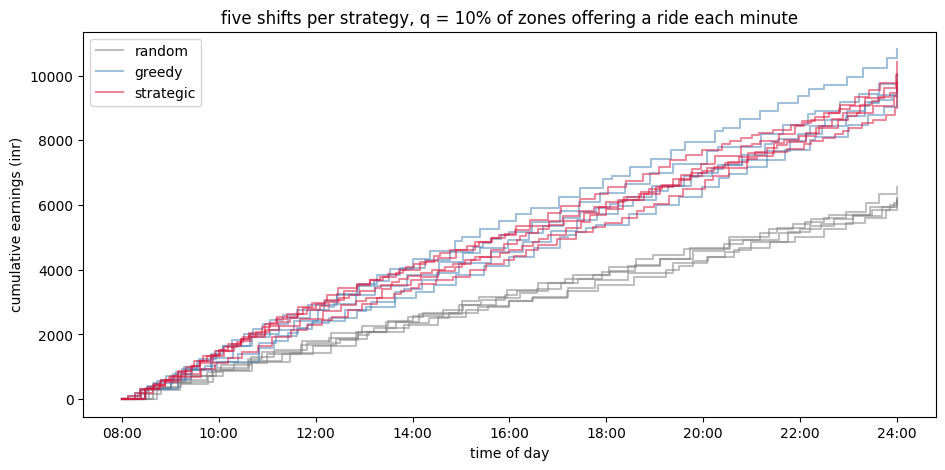

In [5]:
colors = {"random": "grey", "greedy": "steelblue", "strategic": "crimson"}

fig, ax = plt.subplots(figsize=(11, 5))
for strat in colors:
    for seed in range(5):
        total, path = one_shift(strat, q, seed)
        ts, cs = zip(*path)
        ax.step(ts, cs, where="post", color=colors[strat], alpha=0.5,
                label=strat if seed == 0 else None)
ax.set_xticks(range(480, 1441, 120), [f"{h:02d}:00" for h in range(8, 25, 2)])
ax.set_xlabel("time of day")
ax.set_ylabel("cumulative earnings (inr)")
ax.legend()
ax.set_title(f"five shifts per strategy, q = {q:.0%} of zones offering a ride each minute");

## turning the knob

sweep q from 2% to 100% availability, 30 days each — how much each strategy earns as the market thickens

random       6,205   6,182   6,178   6,201   6,257   6,178
greedy       7,550   8,930   9,853  10,775  12,272  15,586
strategic    7,360   8,665   9,653  10,837  12,889  16,022


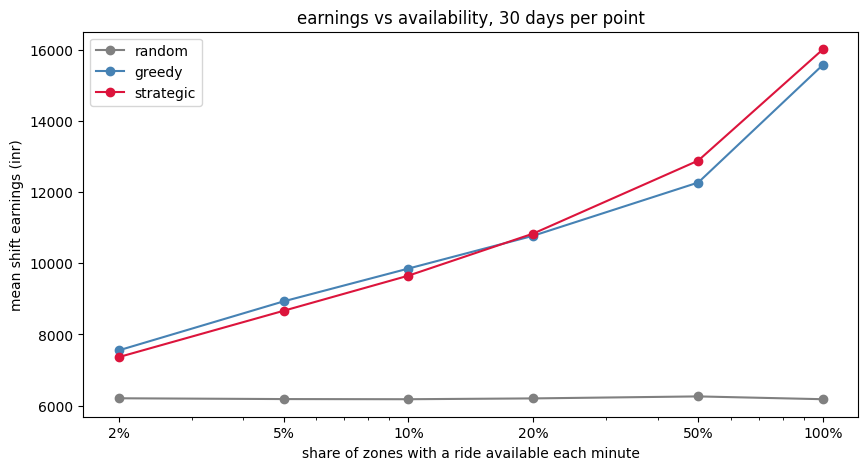

In [6]:
qs = [0.02, 0.05, 0.10, 0.20, 0.50, 1.00]
DAYS = 30
means = {s: [] for s in colors}
for qq in qs:
    for strat in colors:
        totals = [one_shift(strat, qq, seed)[0] for seed in range(DAYS)]
        means[strat].append(np.mean(totals))

fig, ax = plt.subplots(figsize=(10, 5))
for strat in colors:
    ax.plot([q * 100 for q in qs], means[strat], "o-", color=colors[strat], label=strat)
ax.set_xscale("log")
ax.set_xticks([2, 5, 10, 20, 50, 100], ["2%", "5%", "10%", "20%", "50%", "100%"])
ax.set_xlabel("share of zones with a ride available each minute")
ax.set_ylabel("mean shift earnings (inr)")
ax.legend()
ax.set_title("earnings vs availability, 30 days per point")

for strat in colors:
    print(f"{strat:10}", " ".join(f"{v:7,.0f}" for v in means[strat]))